In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import wfdb

## Label Extraction from Machine Measurements

In [2]:
mm = pd.read_csv('../data/metadata/machine_measurements.csv')
mm.columns

/var/folders/xn/jck3v4qd58xgkpg5jx9v99tm0000gn/T/ipykernel_40397/171072781.py:1: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  mm = pd.read_csv('../data/metadata/machine_measurements.csv')


Index(['subject_id', 'study_id', 'cart_id', 'ecg_time', 'report_0', 'report_1',
       'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7',
       'report_8', 'report_9', 'report_10', 'report_11', 'report_12',
       'report_13', 'report_14', 'report_15', 'report_16', 'report_17',
       'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end',
       'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis'],
      dtype='object')

In [3]:
mm[['report_0', 'report_1',
       'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7',
       'report_8', 'report_9', 'report_10', 'report_11', 'report_12',
       'report_13', 'report_14', 'report_15', 'report_16', 'report_17']].head()

,report_0,report_1,report_2,report_3,report_4,report_5,report_6,report_7,report_8,report_9,report_10,report_11,report_12,report_13,report_14,report_15,report_16,report_17
0,Sinus rhythm,Possible right atrial abnormality,NaN,Borderline ECG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sinus rhythm,Possible right atrial abnormality,NaN,Borderline ECG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sinus tachycardia,NaN,Normal ECG except for rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Sinus rhythm,NaN,Normal ECG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Sinus rhythm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
report_cols = [f"report_{i}" for i in range(18)]

mm["machine_report"] = (
    mm[report_cols]
    .fillna("")
    .agg(" | ".join, axis=1)
    .str.lower()
)

In [5]:
mm["machine_report"].str.contains("atrial fibrillation").sum()

np.int64(80768)

In [6]:
mm["machine_report"].str.contains("normal ecg").sum()

np.int64(516011)

In [7]:
mm["machine_report"].value_counts().head(20)

machine_report
sinus rhythm |  | normal ecg |  |  |  |  |  |  |  |  |  |  |  |  |  |  |                                                          91999
sinus rhythm |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |  |                                                                    20262
sinus bradycardia |  | normal ecg except for rate |  |  |  |  |  |  |  |  |  |  |  |  |  |  |                                     18687
sinus rhythm. |  | normal ecg |  |  |  |  |  |  |  |  |  |  |  |  |  |  |                                                         14511
sinus tachycardia |  | normal ecg except for rate |  |  |  |  |  |  |  |  |  |  |  |  |  |  |                                      7077
ventricular pacing | pacemaker rhythm - no further analysis |  | abnormal ecg |  |  |  |  |  |  |  |  |  |  |  |  |  |             6298
sinus rhythm | inferior t wave changes are nonspecific |  | borderline ecg |  |  |  |  |  |  |  |  |  |  |  |  |  |                5209
sinus rhythm | anterior t wave ch

## Creating Binary Labels for Classification Tasks
- **is_af**: is afibrillation
- **is_normal**: is normal (healthy) ecg reading
- **is_abnormal**: is not a normal ecg reading excluding rhythmic abnormality (which is afib)

In [8]:
mm[mm["machine_report"].str.contains("atrial fibrillation")]["machine_report"].head(10)

33     atrial fibrillation with pvc(s) or aberrant ve...
48     atrial fibrillation. | inferior/lateral st-t c...
49     probable atrial fibrillation with pvc(s) or ab...
97     atrial fibrillation with slow ventricular resp...
98     atrial fibrillation | rightward axis | right b...
99     atrial fibrillation. | indeterminate axis | ri...
100    atrial fibrillation with slow ventricular resp...
101    atrial fibrillation | right bundle branch bloc...
120    atrial fibrillation with pvc(s) | left axis de...
136    atrial fibrillation with pvcs. | left bundle b...
Name: machine_report, dtype: object

In [9]:
mm["is_af"] = mm["machine_report"].str.contains(r"\batrial fibrillation\b", regex=True, na=False)

mm["is_normal"] = mm["machine_report"].str.contains(r"\bnormal ecg\b", regex=True, na=False)
mm["is_borderline"] = mm["machine_report"].str.contains(r"\bborderline ecg\b", regex=True, na=False)
mm["is_abnormal"] = mm["machine_report"].str.contains(r"\babnormal ecg\b", regex=True, na=False)

mm[["is_af", "is_normal", "is_borderline", "is_abnormal"]].sum()

is_af             80768
is_normal        156707
is_borderline    172925
is_abnormal      359304
dtype: int64

In [10]:
mm.loc[mm["is_normal"], "machine_report"].head(20)

2     sinus tachycardia |  | normal ecg except for r...
3     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
6     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
19    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
21    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
23    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
28    sinus tachycardia |  | normal ecg except for r...
29    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
65    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
67    sinus tachycardia |  | normal ecg except for r...
68    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
69    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
70    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
71    sinus rhythm | within normal limits |  | summa...
72    sinus rhythm | rsr'(v1) - probable normal vari...
86    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
89    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
90    sinus bradycardia |  | normal ecg except f

In [11]:
report = mm["machine_report"].fillna("")

mm["is_af"] = (
    report.str.contains(r"\batrial fibrillation\b", regex=True, na=False)
    & ~report.str.contains(r"\batrial flutter\b", regex=True, na=False)
)

mm["is_normal_strict"] = (
    (
        report.str.contains(r"\bnormal ecg\b", regex=True, na=False) |
        report.str.contains(r"\bwithin normal limits\b", regex=True, na=False)
    )
    &
    ~report.str.contains(
        r"\babnormal ecg\b|"
        r"\bborderline ecg\b|"
        r"\bexcept for\b|"
        r"\bprobable\b|"
        r"\bpossible\b|"
        r"\bpvc\b|"
        r"\bpac\b|"
        r"\bblock\b|"
        r"\binfarct\b|"
        r"\bst-t\b|"
        r"\bt wave\b|"
        r"\batrial\b|"
        r"\bventricular\b|"
        r"\btachycardia\b|"
        r"\bbradycardia\b|"
        r"\barrhythmia\b",
        regex=True,
        na=False
    )
)

In [12]:
print(mm["is_af"].sum())
mm.loc[mm["is_af"], "machine_report"].sample(20, random_state=42)

80768


254100    atrial fibrillation with slow ventricular resp...
169393    atrial fibrillation with pvc(s) | lateral t wa...
465242    atrial fibrillation | left axis deviation | rb...
512899    atrial fibrillation |  | abnormal ecg |  |  | ...
274787    atrial fibrillation | abnormal r-wave progress...
65719     atrial fibrillation | left axis deviation | in...
621154    atrial fibrillation. | cannot rule out anteros...
406693    atrial fibrillation | abnormal r-wave progress...
188288    atrial fibrillation with rapid ventricular res...
243164    atrial fibrillation | probable lvh with second...
154909    atrial fibrillation | poor r wave progression ...
208104    atrial fibrillation | extensive st-t changes m...
303632    --- warning: data quality may affect interpret...
528931    atrial fibrillation | prolonged qt interval | ...
79218     atrial fibrillation with rapid ventricular res...
316780    atrial fibrillation |  | abnormal ecg |  |  | ...
306366    atrial fibrillation. | severe 

In [13]:
print(mm["is_normal_strict"].sum())
mm.loc[mm["is_normal_strict"], "machine_report"].head(30)

112237


3      sinus rhythm |  | normal ecg |  |  |  |  |  | ...
6      sinus rhythm |  | normal ecg |  |  |  |  |  | ...
19     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
21     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
23     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
29     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
65     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
68     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
69     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
70     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
71     sinus rhythm | within normal limits |  | summa...
86     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
89     sinus rhythm |  | normal ecg |  |  |  |  |  | ...
178    sinus rhythm. |  | normal ecg |  |  |  |  |  |...
187    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
243    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
246    sinus rhythm |  | normal ecg |  |  |  |  |  | ...
248    sinus rhythm |  | normal

In [14]:
mm["is_clearly_abnormal"] = (
    report.str.contains(r"\babnormal ecg\b", regex=True, na=False)
    & ~mm["is_af"]
)
mm["is_clearly_abnormal"].sum()

np.int64(286837)

#### AF cohort

Atrial fibrillation (AF) was defined from machine-generated interpretation text by the presence of the phrase “atrial fibrillation.” Reports containing “atrial flutter” were excluded to avoid mixing related but distinct atrial rhythm phenotypes, but found that there were no records with this overlap. AF reports were retained even when accompanied by additional descriptors such as ventricular response, PVCs, axis changes, or conduction findings.

#### Strict normal cohort

Strict normal ECGs were defined from the machine-generated report text as records containing either “normal ecg” or “within normal limits”, while excluding any report containing language suggestive of abnormality, uncertainty, rhythm disturbance, or additional findings. Exclusion terms included: “abnormal ecg,” “borderline ecg,” “except for,” “probable,” “possible,” “pvc,” “pac,” “block,” “infarct,” “st-t,” “t wave,” “atrial,” “ventricular,” “tachycardia,” “bradycardia,” and “arrhythmia.” This stricter definition was used to create a cleaner baseline class for downstream modeling.

#### Clearly abnormal cohort

Clearly abnormal ECGs were defined as records whose machine-generated report text contained “abnormal ecg” and did not meet criteria for atrial fibrillation. This definition was intentionally conservative, focusing on ECGs explicitly flagged as abnormal by the machine interpretation while separating them from the rhythm-specific AF cohort.

## Build Final Metadata Dataset
Connecting the labels we just created to the waveform paths.

In [15]:
records = pd.read_csv('../data/metadata/record_list.csv')
records.head()

,subject_id,study_id,file_name,ecg_time,path
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311
3,10000117,45090959,45090959,2181-03-04 17:14:00,files/p1000/p10000117/s45090959/45090959
4,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569


In [16]:
META = records.merge(
    mm[
        [
            "subject_id",
            "study_id",
            "machine_report",
            "is_af",
            "is_normal_strict",
            "is_clearly_abnormal"
        ]
    ],
    on=['subject_id', 'study_id'],
    how='inner'
)

In [17]:
META

,subject_id,study_id,file_name,ecg_time,path,machine_report,is_af,is_normal_strict,is_clearly_abnormal
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238,sinus rhythm | possible right atrial abnormali...,False,False,False
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630,sinus rhythm | possible right atrial abnormali...,False,False,False
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311,sinus tachycardia | | normal ecg except for r...,False,False,False
3,10000117,45090959,45090959,2181-03-04 17:14:00,files/p1000/p10000117/s45090959/45090959,sinus rhythm | | normal ecg | | | | | | ...,False,True,False
4,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569,sinus rhythm | | | | | | | | | | | ...,False,False,False
...,...,...,...,...,...,...,...,...,...
800030,19999840,48683947,48683947,2164-09-12 12:28:00,files/p1999/p19999840/s48683947/48683947,sinus rhythm. | left axis deviation | | borde...,False,False,False
800031,19999840,41842293,41842293,2164-09-17 11:31:00,files/p1999/p19999840/s41842293/41842293,accelerated idioventricular rhythm. | left axi...,False,False,True
800032,19999987,41190887,41190887,2145-11-02 19:54:00,files/p1999/p19999987/s41190887/41190887,sinus tachycardia with pvc(s). | possible righ...,False,False,False
800033,19999987,45828463,45828463,2145-11-03 03:00:00,files/p1999/p19999987/s45828463/45828463,sinus rhythm. | | normal ecg | | | | | |...,False,True,False


In [18]:
META[["is_af","is_normal_strict","is_clearly_abnormal"]].sum()

is_af                   80768
is_normal_strict       112237
is_clearly_abnormal    286837
dtype: int64

In [19]:
len(META)

800035

## Creating Classification Task Subsets
To evaluate the ability of classical ECG signal-processing features and learned ECG embeddings to capture clinically meaningful information, two binary classification tasks were defined using rule-based labels derived from machine-generated ECG interpretation text.

### Task 1: Atrial Fibrillation Detection

The first task focuses on detecting atrial fibrillation (AF), a common cardiac arrhythmia characterized by irregular atrial activity and highly variable ventricular response.

AF labels were derived from the machine interpretation text by identifying reports containing the phrase “atrial fibrillation.” Records containing “atrial flutter” were excluded to avoid mixing related but distinct atrial rhythm phenotypes.

To construct a clean comparison group, AF-positive recordings were contrasted against a strict normal ECG cohort defined from machine reports containing “normal ecg” or “within normal limits.” Additional filtering removed reports containing uncertainty language or indications of abnormality (e.g., “borderline,” “possible,” “probable,” “block,” “tachycardia,” “bradycardia,” “arrhythmia,” etc.).

This resulted in a dataset consisting of:
- AF recordings: 80,768
- Strict normal ECG recordings: 112,237

This task emphasizes rhythm irregularity, where both classical signal-processing features (e.g., RR interval variability and entropy) and representation learning methods may capture discriminative information.

### Task 2: Normal vs. Abnormal ECG Classification

The second task evaluates the ability of models to detect broader ECG abnormalities.

**Strict normal ECGs**: Defined as machine reports containing “normal ecg” or “within normal limits” while excluding reports containing terms indicating abnormality, uncertainty, or additional findings (e.g., “abnormal ecg,” “borderline,” “block,” “infarct,” “st-t changes,” “tachycardia,” “bradycardia,” “arrhythmia,” etc.).

**Clearly abnormal ECGs**: Defined as records whose machine interpretation explicitly contained “abnormal ecg.” AF recordings were excluded from this cohort to prevent overlap with the rhythm-specific AF classification task.

The resulting dataset consisted of:
- Strict normal ECGs: 112,237
- Clearly abnormal ECGs: 286,837

This task focuses primarily on morphological and conduction abnormalities, including axis deviations, conduction defects, and repolarization changes.

In [20]:
afib = META[
    META["is_af"] | META["is_normal_strict"]
].copy()

afib["label"] = afib["is_af"].astype(int)

In [21]:
afib['label'].value_counts()

label
0    112237
1     80768
Name: count, dtype: int64

In [22]:
norm = META[
    META["is_normal_strict"] | META["is_clearly_abnormal"]
].copy()

norm["label"] = norm["is_clearly_abnormal"].astype(int)

In [23]:
norm['label'].value_counts()

label
1    286837
0    112237
Name: count, dtype: int64

In [24]:
META.groupby(
    ["is_af","is_normal_strict","is_clearly_abnormal"]
).size().sort_values(ascending=False).head()

is_af  is_normal_strict  is_clearly_abnormal
False  False             False                  320193
                         True                   286837
       True              False                  112237
True   False             False                   80768
dtype: int64

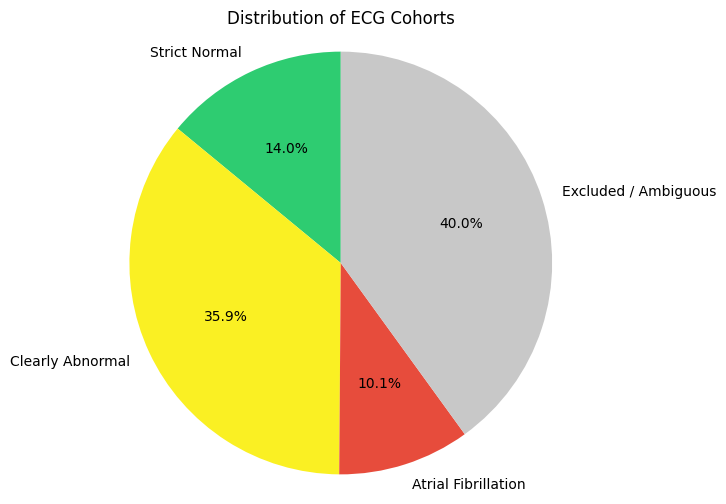

In [46]:
# compute counts
af = META["is_af"].sum()
normal = META["is_normal_strict"].sum()
abnormal = META["is_clearly_abnormal"].sum()

included = META["is_af"] | META["is_normal_strict"] | META["is_clearly_abnormal"]
excluded = (~included).sum()

labels = [
    "Strict Normal",
    "Clearly Abnormal",
    "Atrial Fibrillation",
    "Excluded / Ambiguous"
]

sizes = [normal, abnormal, af, excluded]

plt.figure(figsize=(6,6))

colors = [
    "#2ecc71",   # Normal
    "#faf023",   # Abnormal
    "#e74c3c",   # AF
    "#c8c8c8"    # Excluded
]

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of ECG Cohorts")
plt.axis("equal")

plt.show()

### Purpose of the Two-Task Design

These two classification tasks capture complementary aspects of ECG physiology:

AF vs Normal -> Rhythm irregularity

Normal vs Abnormal -> Morphological / conduction abnormalities

This design enables evaluation of whether learned ECG representations capture signal characteristics beyond those obtained from classical signal-processing features across both rhythm-based and morphology-based classification problems.

### Saving Processed Datasets
We did not restrict ECGs to those overlapping with hospital or emergency department visits, since the classification labels were derived directly from machine-generated ECG interpretation text rather than encounter-level diagnoses. This allowed inclusion of a larger set of waveform-label pairs while avoiding additional uncertainty from imperfect timestamp alignment between ECG acquisition systems and the clinical database.

### Subset Selection
Due to the large size of the MIMIC-IV-ECG dataset and computational constraints associated with downloading and processing hundreds of thousands of waveforms, experiments were conducted on a stratified subset of labeled recordings. A balanced subset was constructed by randomly sampling 5,000 atrial fibrillation (AF) ECGs, 5,000 strictly normal ECGs, and 5,000 clearly abnormal ECGs from the full labeled dataset. The same set of strictly normal ECGs was used as the control group for both classification tasks. This resulted in two task-specific datasets: AF vs. Normal and Abnormal vs. Normal, each containing 10,000 recordings. Using a shared normal cohort provides a consistent baseline for comparing rhythm-based and morphology-based classification performance while keeping the total number of downloaded waveforms manageable.

In [27]:
normal_sub = META[META["is_normal_strict"]].sample(5000, random_state=67)
af_sub = META[META["is_af"]].sample(5000, random_state=67)
abnormal_sub = META[META["is_clearly_abnormal"]].sample(5000, random_state=67)

In [39]:
afib_sub = pd.concat([af_sub, normal_sub]).sort_index()
afib_sub["label"] = afib_sub["is_af"].astype(int)

norm_sub = pd.concat([abnormal_sub, normal_sub]).sort_index()
norm_sub["label"] = norm_sub["is_clearly_abnormal"].astype(int)

In [40]:
afib_sub

,subject_id,study_id,file_name,ecg_time,path,machine_report,is_af,is_normal_strict,is_clearly_abnormal,label
97,10001860,45808859,45808859,2188-03-28 07:39:00,files/p1000/p10001860/s45808859/45808859,atrial fibrillation with slow ventricular resp...,True,False,False,1
243,10002157,41748669,41748669,2120-12-20 20:53:00,files/p1000/p10002157/s41748669/41748669,sinus rhythm | | normal ecg | | | | | | ...,False,True,False,0
381,10003400,45036862,45036862,2134-04-04 14:44:00,files/p1000/p10003400/s45036862/45036862,atrial fibrillation | leftward axis | qrs chan...,True,False,False,1
389,10003400,47684518,47684518,2137-03-01 21:49:00,files/p1000/p10003400/s47684518/47684518,atrial fibrillation with rapid ventricular res...,True,False,False,1
391,10003400,47771850,47771850,2137-03-17 05:13:00,files/p1000/p10003400/s47771850/47771850,atrial fibrillation with rapid ventricular res...,True,False,False,1
...,...,...,...,...,...,...,...,...,...,...
799544,19993951,41876706,41876706,2140-03-28 14:15:00,files/p1999/p19993951/s41876706/41876706,atrial fibrillation | prolonged qt interval | ...,True,False,False,1
799556,19993951,43560949,43560949,2141-08-14 13:34:00,files/p1999/p19993951/s43560949/43560949,atrial fibrillation | severe right axis deviat...,True,False,False,1
799684,19995495,42036572,42036572,2191-04-02 19:06:00,files/p1999/p19995495/s42036572/42036572,sinus rhythm | | normal ecg | | | | | | ...,False,True,False,0
799957,19998562,45374198,45374198,2166-03-21 20:31:00,files/p1999/p19998562/s45374198/45374198,sinus rhythm | | normal ecg | | | | | | ...,False,True,False,0


## Extracting Waveforms from MIMIC-IV-ECG

In [30]:
# paths_af = set(afib["path"])
# paths_norm = set(norm["path"])

paths_af = set(afib_sub["path"])
paths_norm = set(norm_sub["path"])

needed_paths = paths_af.union(paths_norm)

len(needed_paths)

15000

#### Downloading Waveforms from MIMIC using aria2c
Create directories first, then produce aria2 input file for parallel downloads from MIMIC-IV-ECG. The bottleneck is that there are almost 1 million tiny files so we are utilizing parallel downloading.

In [31]:
ROOT = Path("../data/raw_waveforms")

for p in needed_paths:
    (ROOT / p).parent.mkdir(parents=True, exist_ok=True)

In [33]:
base_url = "https://physionet.org/files/mimic-iv-ecg/1.0"

with open("../utils/aria2_input.txt", "w") as f:
    for p in sorted(needed_paths):
        for ext in [".hea", ".dat"]:
            rel = f"{p}{ext}"
            url = f"{base_url}/{rel}"
            out_path = f"../data/raw_waveforms/{rel}"

            f.write(url + "\n")
            f.write(f"  out={out_path}\n")

Terminal script for parallel waveform file requests. Even with 32 parallel downloads, it will take about 2-3 hours to get every file.